# DentalVision - Model Training

This notebook trains an EfficientNetB0 model to classify dental diseases from cropped dental X-ray images.

In [1]:
import os
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [2]:
print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPU: []


In [3]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [4]:
DATASET_PATH = pathlib.Path(r"D:\FYP\dental-vision\ML\data\processed")

TRAIN_PATH = DATASET_PATH / "train"
VALID_PATH = DATASET_PATH / "valid"
TEST_PATH = DATASET_PATH / "test"

MODEL_PATH = pathlib.Path(r"D:\FYP\dental-vision\ML\models")
MODEL_PATH.mkdir(exist_ok=True)

In [23]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 10

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 35437 files belonging to 5 classes.
Found 7595 files belonging to 5 classes.
Found 7596 files belonging to 5 classes.


In [7]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Classes:
['Bone_Loss', 'Caries', 'Impacted_Tooth', 'Missing_Teeth', 'Periapical_Lesion']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
valid_dataset = valid_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

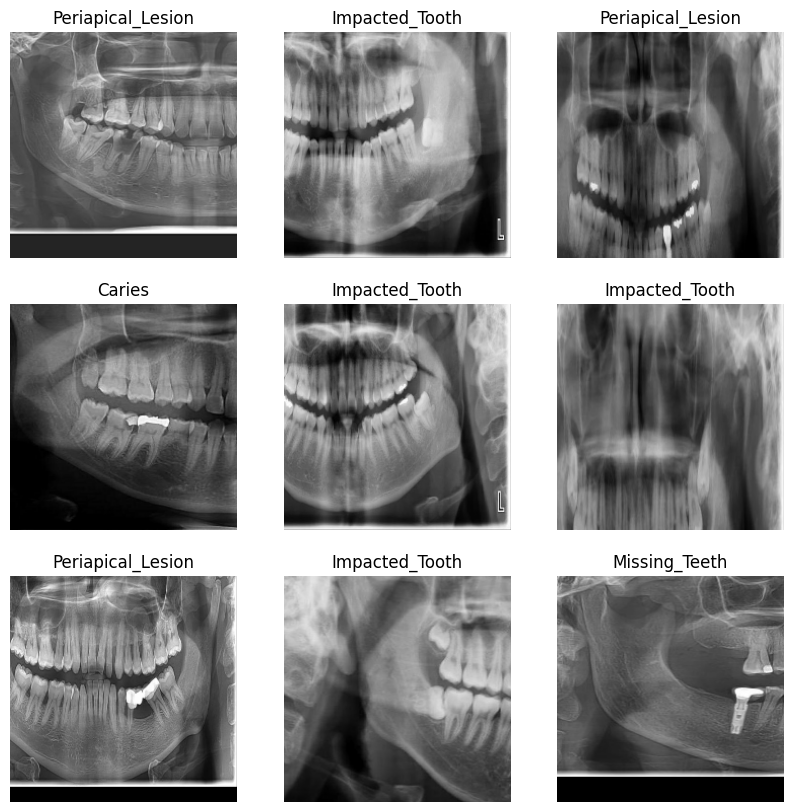

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [11]:
labels = []

for _, y in train_dataset:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(3.234778639890461), 1: np.float64(0.9442312816413536), 2: np.float64(0.36189746732026146), 3: np.float64(2.8892784345699143), 4: np.float64(1.9139616527140157)}


In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [13]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [14]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [15]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    MODEL_PATH / "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [22]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 697s 625ms/step - accuracy: 0.5700 - loss: 1.2363 - val_accuracy: 0.4465 - val_loss: 1.3642 - learning_rate: 0.0010
Epoch 2/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 662s 597ms/step - accuracy: 0.6125 - loss: 1.1448 - val_accuracy: 0.4737 - val_loss: 1.3231 - learning_rate: 0.0010
Epoch 3/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 654s 590ms/step - accuracy: 0.6218 - loss: 1.1260 - val_accuracy: 0.5331 - val_loss: 1.1859 - learning_rate: 0.0010
Epoch 4/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 657s 593ms/step - accuracy: 0.6194 - loss: 1.1210 - val_accuracy: 0.5085 - val_loss: 1.2154 - learning_rate: 0.0010
Epoch 5/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 662s 597ms/step - accuracy: 0.6240 - loss: 1.1074 - val_accuracy: 0.4824 - val_loss: 1.2815 - learning_rate: 0.0010
Epoch 6/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 714s 644ms/step - accuracy: 0.6250 - loss: 1.1072 - val_accuracy: 0.4583 - val_loss: 1.3313 - learning_rate: 0.0010
Epoch 7/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 910s 821ms